# California Housing Price Prediction with Neural Networks

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

ds = load_dataset("leostelon/california-housing")

ds_train = ds['train']

df = ds_train.to_pandas()

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']



## 1. Data Loading and Initial Split

In [42]:
X = pd.get_dummies(
    X,
    columns=["ocean_proximity"],
    drop_first=True
)

## 2. Data Preprocessing

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Feature Scaling

In [45]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 3. Neural Network Model Architecture

In [46]:
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Reduced learning rate
    loss='mse',
    metrics=['mae']
)

## 4. Model Compilation

In [55]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    verbose=1
)

Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 55396196352.0000 - mae: 205508.6562 - val_loss: 56042078208.0000 - val_mae: 206264.8438
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 55256195072.0000 - mae: 205229.2969 - val_loss: 55895576576.0000 - val_mae: 205974.0156
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 55105765376.0000 - mae: 204930.1562 - val_loss: 55739715584.0000 - val_mae: 205664.2031
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 54945169408.0000 - mae: 204608.3750 - val_loss: 55572377600.0000 - val_mae: 205330.9688
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 54773846016.0000 - mae: 204265.0469 - val_loss: 55395274752.0000 - val_mae: 204977.4531
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 54593114112.0000 - mae: 203903.2031 - val_loss: 55208976384.0000 - val_mae: 204604.8438
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 54403305472.0000 - mae: 203521.0625 - val_loss: 5501

## 5. Model Training

In [56]:
print(f"Training MAE: {history.history['mae'][-1]:.2f}")
print(f"Validation MAE: {history.history['val_mae'][-1]:.2f}")

Training MAE: 199803.09
Validation MAE: 200420.91


## 6. Model Prediction and Evaluation

In [57]:
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step


### Test Set Predictions

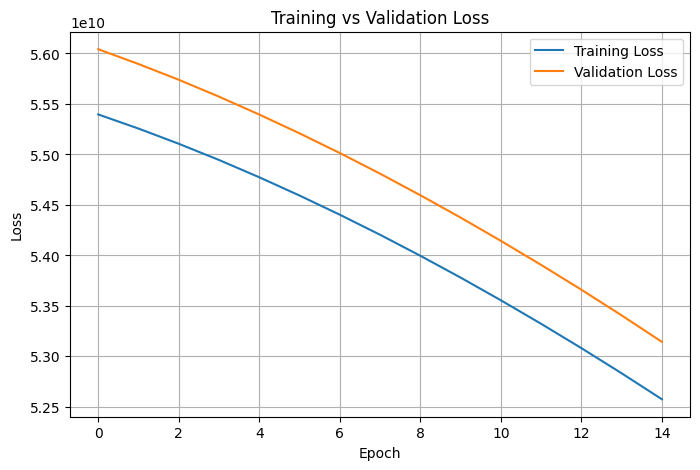

In [58]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

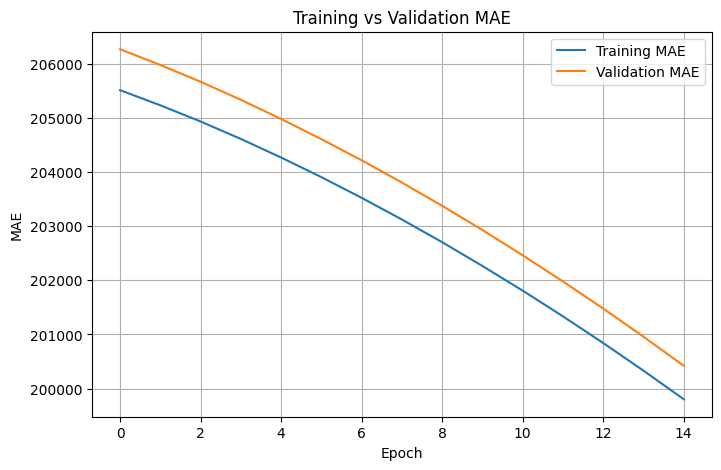

In [59]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.grid(True)

plt.show()

## 7. Save Model

In [60]:
model.save("california_regression.keras")